# GISLR — Landmark Motion-Over-Time Analysis

Diagnostic notebook (pre-training, **not** part of the train pipeline). Measures how
much each landmark moves over time — per-landmark **RMS speed** — at three scopes:

| scope | sample | resumable unit | output (under `cache/motion_analysis/`) |
|---|---|---|---|
| 1 — per-video | 50 random videos (seed 42) | video | `per_video/summary.parquet` + one PNG per video |
| 2 — per-category | 10 random signs (seed 42) | sign | `per_category/summary.parquet` |
| 3 — global | all 94,477 videos | 500-video chunk | `global/summary.parquet` |

**Resumability:** every scope runs through the same manifest-driven loop
(`process_units`). Interrupt at any point and re-run the notebook top to bottom —
`done` units are skipped, `failed` units are retried. Per-unit artifacts are written
*before* being marked `done`, so a crash can never leave the manifest pointing at a
missing/corrupt file. Final aggregations read only the cached per-unit files.

**Design decisions (vs the original TODO §1 spec):**
- `load_landmarks_for_paths` passes an explicit parquet file list to `read_parquet`
  instead of filtering a 94K-file glob view — this guarantees DuckDB opens only the
  requested files. (A `meta_holistic` glob view is still created for ad-hoc SQL.)
- Global scope (§1.5 decision): full in-SQL aggregation was **rejected** because
  Savitzky-Golay needs ordered per-frame series, which SQL can't express cleanly.
  Instead: chunked Python compute (resumable), then in-SQL aggregation over the
  cached chunk parquets — the memory-bounded part still happens in DuckDB.
- Measured throughput ≈ 65 videos/s single-threaded → full global scope ≈ 25 min.

**NaN policy** (hands are absent in many frames): a landmark's speed at transition
t→t+1 counts toward its RMS only when the landmark was detected at **both** t and
t+1 in the raw data. Absent stretches are interpolated for smoothing but never
scored — so a hand seen in 20% of frames is measured on those frames, not diluted
by interpolated stillness. Landmarks with zero valid transitions get `rms_speed = NaN`.

In [1]:
# ============================================================
# Imports & config
# ============================================================
import json
import os
from datetime import datetime, timezone
from pathlib import Path

import duckdb
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
from scipy.stats import spearmanr
from tqdm.auto import tqdm

# GISLR competition data, resolved from kagglehub's cache (downloads on first use).
# Deliberately NOT `from modules.paths import DATASETS` — importing modules.paths
# triggers kagglehub downloads for every dataset (incl. POPSIGN) at import time.
DATA_DIR = Path(kagglehub.competition_download("asl-signs"))

CACHE_DIR = Path("cache")
MOTION_CACHE_DIR = CACHE_DIR / "motion_analysis"
MOTION_CACHE_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42                 # every sampling step below uses this seed
SAVGOL_WINDOW = 7         # frames — carried over from earlier motion-energy findings
SAVGOL_POLYORDER = 2
N_PER_VIDEO_SAMPLES = 50  # scope 1
N_CATEGORY_SAMPLES = 10   # scope 2
LOAD_BATCH = 100          # videos per DuckDB read — bounds peak memory
CHUNK_SIZE = 500          # videos per resumable unit in the global scope

TYPE_ORDER = ["pose", "left_hand", "right_hand", "face"]
TYPE_COLORS = {"pose": "tab:blue", "left_hand": "tab:orange",
               "right_hand": "tab:green", "face": "tab:red"}

print("DATA_DIR:", DATA_DIR)
print("cache   :", MOTION_CACHE_DIR.resolve())

DATA_DIR: C:\Users\user2\.cache\kagglehub\competitions\asl-signs
cache   : C:\Users\user2\sign2speech\src\cache\motion_analysis


## 1. Reusable core (TODO §1.1)

Four functions, built once, used by all three scopes:
`get_duckdb_conn` → `load_landmarks_for_paths` → `compute_motion_energy` → `plot_motion_gridspec`.
Each gets an immediate smoke test on one seeded random video.

In [2]:
# ============================================================
# get_duckdb_conn()
# ============================================================
def get_duckdb_conn(data_dir: Path) -> duckdb.DuckDBPyConnection:
    """In-memory DuckDB with a `meta` view over train.csv.

    `abs_path` (forward slashes) is what landmark loads join against, so path
    normalization lives in exactly one place.
    """
    con = duckdb.connect(database=":memory:")
    root = data_dir.as_posix()
    con.execute(f"""
        CREATE OR REPLACE VIEW meta AS
        SELECT path, participant_id, sequence_id, sign,
               '{root}/' || path AS abs_path
        FROM read_csv_auto('{root}/train.csv')
    """)
    # Ad-hoc convenience view joining metadata to ALL landmark parquets via glob.
    # WARNING: any query that doesn't filter hard scans ~94K files. The scopes
    # below never use it — they go through load_landmarks_for_paths(), which
    # hands DuckDB an explicit file list so only requested files are opened.
    con.execute(f"""
        CREATE OR REPLACE VIEW meta_holistic AS
        SELECT m.sequence_id AS video_id, m.sign, l.*
        FROM read_parquet('{root}/train_landmark_files/*/*.parquet', filename=true) l
        JOIN meta m ON replace(l.filename, '\\', '/') = m.abs_path
    """)
    return con


con = get_duckdb_conn(DATA_DIR)
# ORDER BY path: read_csv_auto is parallel and does not guarantee row order —
# a deterministic meta order is what makes the seeded sampling reproducible.
meta = con.execute("SELECT * FROM meta ORDER BY path").df()
print(f"{len(meta):,} videos · {meta['sign'].nunique()} signs · "
      f"{meta['participant_id'].nunique()} participants")

94,477 videos · 250 signs · 21 participants


In [3]:
# ============================================================
# load_landmarks_for_paths() — the one loading function every scope calls
# ============================================================
def load_landmarks_for_paths(
    con: duckdb.DuckDBPyConnection,
    paths: list[str],
    data_dir: Path = DATA_DIR,
) -> pd.DataFrame:
    """Load landmark rows (+ sign metadata) for train.csv-relative parquet paths."""
    abs_paths = [(data_dir / p).as_posix() for p in paths]
    return con.execute("""
        SELECT m.sequence_id    AS video_id,
               m.sign           AS sign,
               l.frame, l.type, l.landmark_index, l.x, l.y, l.z
        FROM read_parquet($paths, filename=true) l
        JOIN meta m ON replace(l.filename, '\\', '/') = m.abs_path
    """, {"paths": abs_paths}).df()


# smoke test — one seeded random video
_smoke_path = meta["path"].sample(1, random_state=SEED).iloc[0]
_smoke_df = load_landmarks_for_paths(con, [_smoke_path])
print(_smoke_path)
print(f"rows={len(_smoke_df):,}  frames={_smoke_df['frame'].nunique()}  "
      f"landmarks/frame={len(_smoke_df) // _smoke_df['frame'].nunique()}")
_smoke_df.head(3)

train_landmark_files/36257/400588337.parquet
rows=8,688  frames=16  landmarks/frame=543


,video_id,sign,frame,type,landmark_index,x,y,z
0,400588337,if,44,right_hand,20,NaN,NaN,NaN
1,400588337,if,44,right_hand,19,NaN,NaN,NaN
2,400588337,if,44,right_hand,18,NaN,NaN,NaN


In [4]:
# ============================================================
# compute_motion_energy()
# ============================================================
def compute_motion_energy(
    df: pd.DataFrame,
    window: int = SAVGOL_WINDOW,
    polyorder: int = SAVGOL_POLYORDER,
) -> pd.DataFrame:
    """Per-landmark RMS speed for every video in `df` (vectorized per video).

    Per video: pivot to (frames × landmarks·xyz), reindex to a contiguous frame
    range (uniform dt), linearly interpolate gaps, Savitzky-Golay smooth every
    coordinate in one call, frame-to-frame speed, then RMS speed — not
    mean-squared. Validity comes from the RAW data (see NaN policy up top).

    Returns tidy long format:
        video_id, sign, type, landmark_index, rms_speed, n_valid_transitions
    """
    out = []
    for (vid, sign), g in df.groupby(["video_id", "sign"], sort=False):
        wide = g.pivot(index="frame", columns=["type", "landmark_index"],
                       values=["x", "y", "z"]).sort_index(axis=1)
        f0, f1 = int(wide.index.min()), int(wide.index.max())
        wide = wide.reindex(np.arange(f0, f1 + 1))
        T = len(wide)
        L = wide.shape[1] // 3

        # x/y/z blocks share one sorted landmark order after sort_index above
        landmark_cols = wide["x"].columns              # MultiIndex (type, landmark_index)
        valid = wide["x"].notna().to_numpy()           # raw validity, pre-fill

        filled = wide.interpolate(method="linear", limit_direction="both").to_numpy()

        if T >= 3:
            w = min(window, T if T % 2 == 1 else T - 1)
            po = min(polyorder, w - 1)
            allnan = np.isnan(filled).all(axis=0)      # never-seen landmarks
            sm = filled.copy()
            sm[:, ~allnan] = savgol_filter(filled[:, ~allnan], w, po, axis=0)
        else:
            sm = filled

        vel = np.diff(sm.reshape(T, 3, L), axis=0)     # (T-1, 3, L)
        speed2 = (vel ** 2).sum(axis=1)                # (T-1, L)
        vt = valid[1:] & valid[:-1]                    # both endpoints observed
        with np.errstate(invalid="ignore", divide="ignore"):
            rms = np.sqrt(np.where(vt, speed2, 0.0).sum(axis=0) / vt.sum(axis=0))

        out.append(pd.DataFrame({
            "video_id": vid,
            "sign": sign,
            "type": landmark_cols.get_level_values(0),
            "landmark_index": landmark_cols.get_level_values(1),
            "rms_speed": rms,
            "n_valid_transitions": vt.sum(axis=0),
        }))
    return pd.concat(out, ignore_index=True)


# smoke test — reuse the loaded single video
_smoke_me = compute_motion_energy(_smoke_df)
assert len(_smoke_me) == 543, f"expected 543 landmark rows, got {len(_smoke_me)}"
_smoke_me.groupby("type", observed=True)["rms_speed"].describe().round(4)

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
face,468.0,0.0021,0.0004,0.0016,0.0019,0.0021,0.0023,0.0034
left_hand,21.0,0.0160,0.0029,0.0129,0.0134,0.0153,0.0175,0.0213
pose,33.0,0.0840,0.0556,0.0040,0.0491,0.0547,0.1098,0.2225
right_hand,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


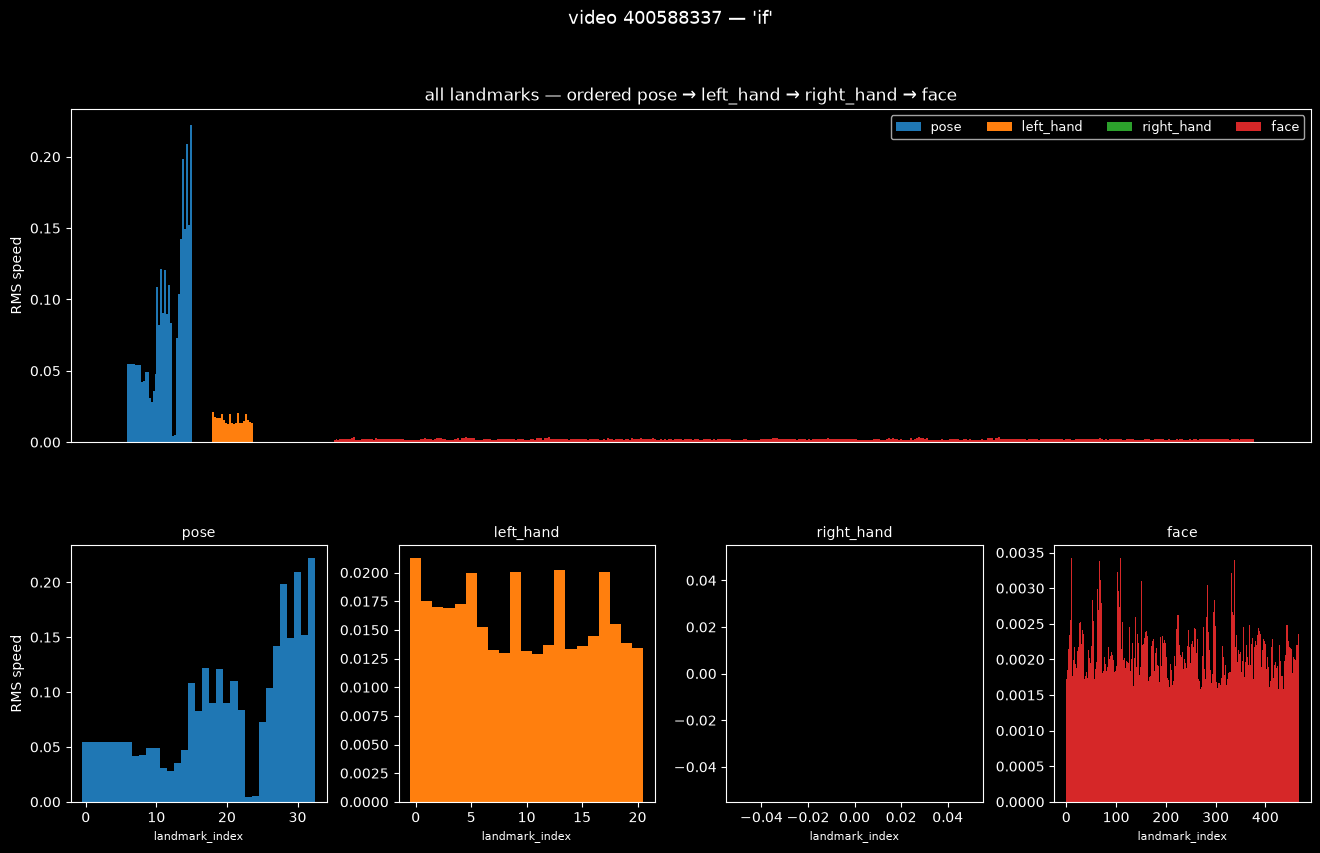

In [5]:
# ============================================================
# plot_motion_gridspec() — one figure layout, shared by all three scopes
# ============================================================
def plot_motion_gridspec(df: pd.DataFrame, title: str,
                         save_path: Path | None = None, show: bool = True) -> None:
    """Combined overview (landmarks ordered pose → left_hand → right_hand → face)
    on top, one panel per landmark type below.

    `df` must hold ONE row per (type, landmark_index). Accepts either a
    per-video frame (`rms_speed`) or an aggregate one (`rms_speed_mean` +
    `rms_speed_std`), detected automatically — std shows as error bars in the
    per-type panels. NaN landmarks (never observed) render as gaps.
    """
    val_col = "rms_speed_mean" if "rms_speed_mean" in df.columns else "rms_speed"
    std_col = "rms_speed_std" if "rms_speed_std" in df.columns else None

    fig = plt.figure(figsize=(16, 9))
    gs = fig.add_gridspec(2, 4, height_ratios=[1.3, 1], hspace=0.35, wspace=0.28)

    ax_top = fig.add_subplot(gs[0, :])
    offset = 0
    for t in TYPE_ORDER:
        sub = df[df["type"] == t].sort_values("landmark_index")
        xs = np.arange(len(sub)) + offset
        ax_top.bar(xs, sub[val_col].to_numpy(), width=1.0,
                   color=TYPE_COLORS[t], label=t)
        offset += len(sub) + 10
    ax_top.set_title("all landmarks — ordered pose → left_hand → right_hand → face")
    ax_top.set_ylabel("RMS speed")
    ax_top.set_xticks([])
    ax_top.legend(ncols=4, fontsize=9)

    for i, t in enumerate(TYPE_ORDER):
        ax = fig.add_subplot(gs[1, i])
        sub = df[df["type"] == t].sort_values("landmark_index")
        yerr = sub[std_col].fillna(0).to_numpy() if std_col else None
        ax.bar(sub["landmark_index"], sub[val_col].to_numpy(), width=1.0,
               color=TYPE_COLORS[t], yerr=yerr,
               error_kw={"elinewidth": 0.4, "alpha": 0.5})
        ax.set_title(t, fontsize=10)
        ax.set_xlabel("landmark_index", fontsize=8)
        if i == 0:
            ax.set_ylabel("RMS speed")

    fig.suptitle(title, fontsize=13, y=0.99)
    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=110, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)


# smoke test
plot_motion_gridspec(
    _smoke_me,
    title=f"video {_smoke_me['video_id'].iloc[0]} — '{_smoke_me['sign'].iloc[0]}'")

## 2. Resumable caching / state management (TODO §1.2)

One manifest per scope at `cache/motion_analysis/<scope>_manifest.json`, tracking
`{unit_id: {status, timestamp, artifact[, error]}}`. The invariants:

1. the per-unit parquet is written **before** the unit is marked `done`;
2. manifest saves are atomic (temp file + `os.replace`);
3. on re-run, `done` units with an existing artifact are skipped, everything else
   (including `failed`) is retried;
4. final aggregation reads only cached per-unit files — never raw parquet.

In [6]:
# ============================================================
# Manifest helpers + the resumable driver every scope runs through
# ============================================================
def _manifest_path(scope: str) -> Path:
    return MOTION_CACHE_DIR / f"{scope}_manifest.json"


def _unit_path(scope: str, unit_id: str) -> Path:
    return MOTION_CACHE_DIR / scope / f"{unit_id}.parquet"


def load_manifest(scope: str) -> dict:
    p = _manifest_path(scope)
    return json.loads(p.read_text()) if p.exists() else {}


def save_manifest(scope: str, manifest: dict) -> None:
    """Atomic write — a crash mid-save can't corrupt the manifest."""
    p = _manifest_path(scope)
    tmp = p.with_suffix(".json.tmp")
    tmp.write_text(json.dumps(manifest, indent=2))
    os.replace(tmp, p)


def process_units(scope: str, unit_ids: list, process_fn, desc: str | None = None) -> dict:
    """Run `process_fn(unit_id) -> DataFrame` over units, resumably.

    Skips units already `done` (with artifact present), retries `failed` ones,
    records exceptions in the manifest instead of aborting the run.
    """
    (MOTION_CACHE_DIR / scope).mkdir(parents=True, exist_ok=True)
    manifest = load_manifest(scope)
    n_skip = n_ok = n_fail = 0
    for uid in tqdm([str(u) for u in unit_ids], desc=desc or scope):
        entry = manifest.get(uid)
        if entry and entry["status"] == "done" and Path(entry["artifact"]).exists():
            n_skip += 1
            continue
        try:
            out = process_fn(uid)
            artifact = _unit_path(scope, uid)
            out.to_parquet(artifact, index=False)      # artifact FIRST …
            manifest[uid] = {"status": "done",         # … then mark done
                             "timestamp": datetime.now(timezone.utc).isoformat(),
                             "artifact": str(artifact)}
            n_ok += 1
        except Exception as e:
            manifest[uid] = {"status": "failed",
                             "timestamp": datetime.now(timezone.utc).isoformat(),
                             "artifact": None, "error": repr(e)}
            n_fail += 1
        save_manifest(scope, manifest)
    print(f"[{scope}] done={n_ok}  skipped={n_skip}  failed={n_fail}")
    if n_fail:
        print("failed units:",
              {k: v["error"] for k, v in manifest.items() if v["status"] == "failed"})
    return manifest


def load_cached_units(scope: str, unit_ids: list) -> pd.DataFrame:
    """Aggregation input: reads ONLY cached per-unit parquets, never raw data."""
    frames = [pd.read_parquet(_unit_path(scope, str(u)))
              for u in unit_ids if _unit_path(scope, str(u)).exists()]
    return pd.concat(frames, ignore_index=True)

## 3. Scope 1 — per-video, 50 random samples (TODO §1.3)

Unit = one video: load → compute → **save PNG** → cache parquet. The exact sample
(seed + paths) is recorded to `per_video_sample.json` for reproducibility.

In [7]:
SCOPE1 = "per_video"
PLOTS_DIR = MOTION_CACHE_DIR / SCOPE1 / "plots"

rng = np.random.default_rng(SEED)
_idx = np.sort(rng.choice(len(meta), size=N_PER_VIDEO_SAMPLES, replace=False))
scope1_meta = meta.iloc[_idx][["path", "sequence_id", "sign"]].reset_index(drop=True)

(MOTION_CACHE_DIR / f"{SCOPE1}_sample.json").write_text(json.dumps(
    {"seed": SEED, "n": N_PER_VIDEO_SAMPLES, "paths": scope1_meta["path"].tolist()},
    indent=2))

_path_by_vid = dict(zip(scope1_meta["sequence_id"].astype(str), scope1_meta["path"]))


def _process_one_video(video_id: str) -> pd.DataFrame:
    me = compute_motion_energy(load_landmarks_for_paths(con, [_path_by_vid[video_id]]))
    plot_motion_gridspec(me, title=f"video {video_id} — '{me['sign'].iloc[0]}'",
                         save_path=PLOTS_DIR / f"{video_id}.png", show=False)
    return me


manifest1 = process_units(SCOPE1, scope1_meta["sequence_id"].tolist(), _process_one_video)

scope1_summary = load_cached_units(SCOPE1, scope1_meta["sequence_id"].tolist())
scope1_summary.to_parquet(MOTION_CACHE_DIR / SCOPE1 / "summary.parquet", index=False)
print(f"summary: {scope1_summary.shape[0]:,} rows "
      f"({scope1_summary['video_id'].nunique()} videos × 543 landmarks)")
scope1_summary.groupby("type", observed=True)["rms_speed"].describe().round(4)

per_video:   0%|          | 0/50 [00:00<?, ?it/s]

[per_video] done=0  skipped=50  failed=0
summary: 27,150 rows (50 videos × 543 landmarks)


,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
face,23400.0,0.0035,0.0023,0.0005,0.0018,0.0029,0.0044,0.0183
left_hand,273.0,0.0236,0.0142,0.0032,0.0130,0.0200,0.0345,0.0756
pose,1650.0,0.0817,0.0585,0.0027,0.0409,0.0673,0.1053,0.4151
right_hand,693.0,0.0224,0.0111,0.0045,0.0136,0.0211,0.0295,0.0719


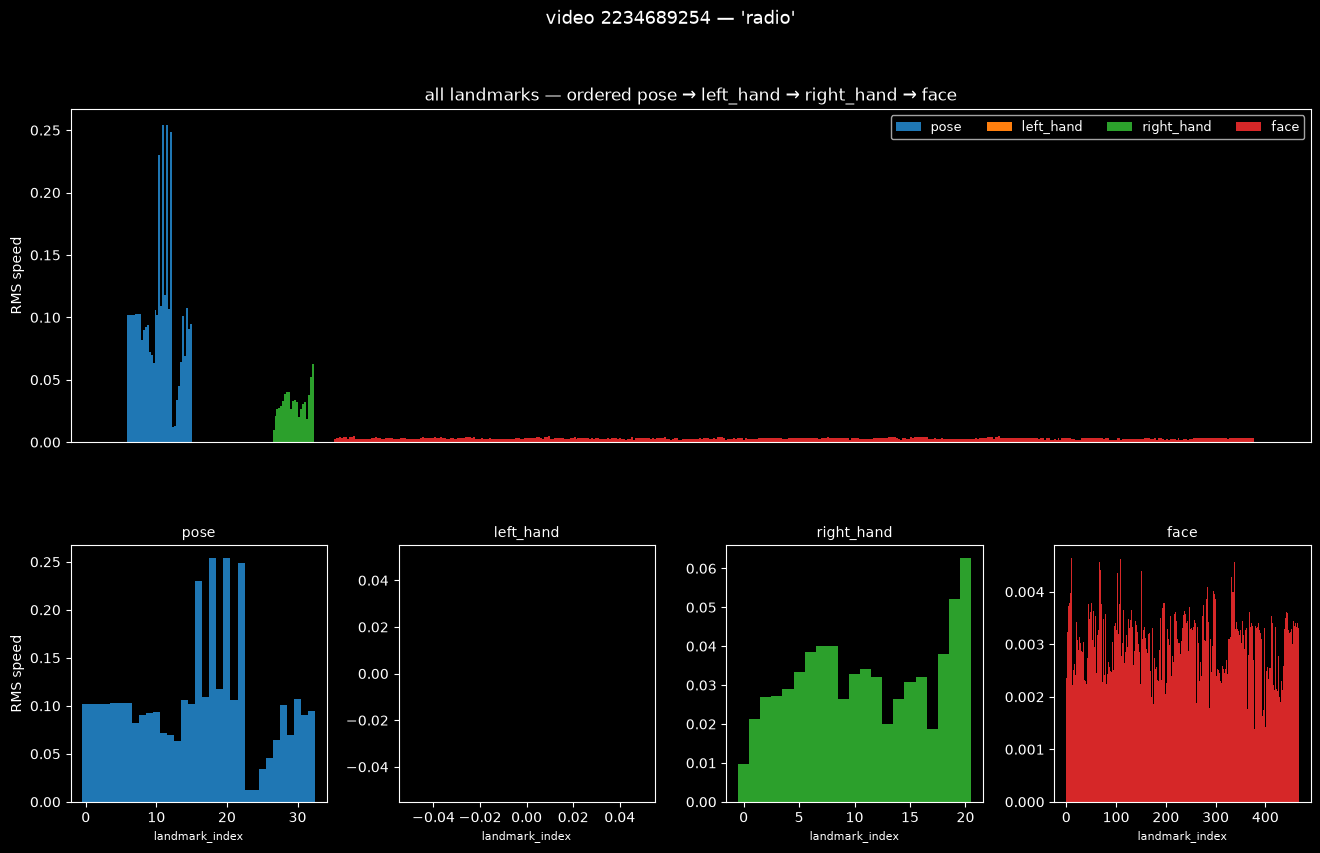

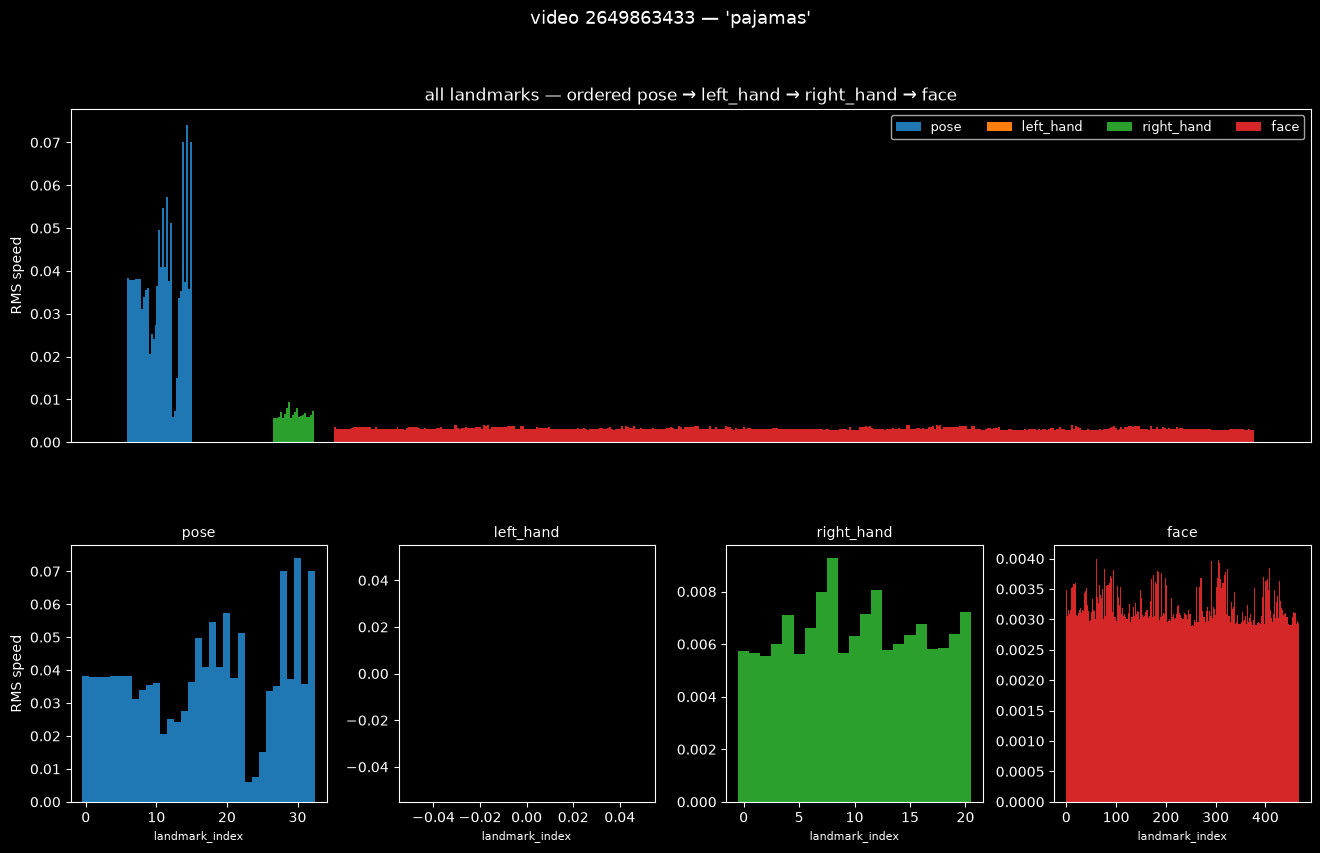

In [8]:
# two example per-video figures inline (all 50 PNGs are in per_video/plots/)
for _vid in scope1_meta["sequence_id"].astype(str).head(2):
    _df_v = pd.read_parquet(_unit_path(SCOPE1, _vid))
    plot_motion_gridspec(_df_v, title=f"video {_vid} — '{_df_v['sign'].iloc[0]}'")

## 4. Scope 2 — per-category, 10 sampled signs (TODO §1.4)

Unit = one sign: batched load of **all** its videos (~375 each) → per-video RMS →
aggregate mean + std per landmark. The std is what the future within-class
consistency analysis feeds on. `n_videos` counts videos where the landmark had at
least one valid transition (NaN rms excluded).

signs: ['beside', 'bird', 'cow', 'hat', 'hate', 'old', 'pizza', 'ride', 'table', 'yourself']
videos per sign: {'beside': 310, 'bird': 404, 'cow': 404, 'hat': 342, 'hate': 358, 'old': 389, 'pizza': 396, 'ride': 347, 'table': 337, 'yourself': 385}


per_category:   0%|          | 0/10 [00:00<?, ?it/s]

[per_category] done=0  skipped=10  failed=0


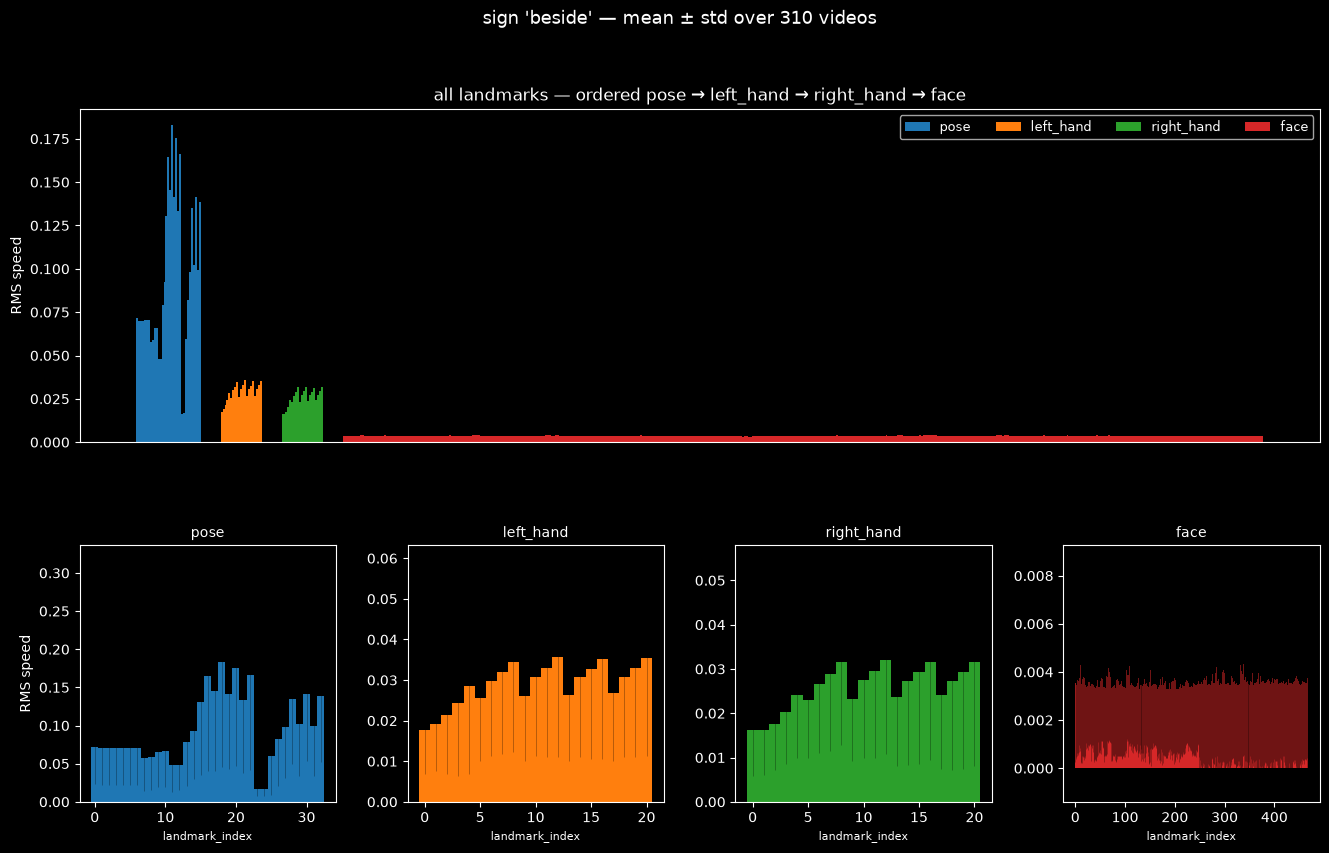

In [9]:
SCOPE2 = "per_category"

rng = np.random.default_rng(SEED)
scope2_signs = sorted(rng.choice(np.sort(meta["sign"].unique()),
                                 size=N_CATEGORY_SAMPLES, replace=False).tolist())

(MOTION_CACHE_DIR / f"{SCOPE2}_sample.json").write_text(json.dumps(
    {"seed": SEED, "n": N_CATEGORY_SAMPLES, "signs": scope2_signs}, indent=2))
print("signs:", scope2_signs)
print("videos per sign:",
      meta[meta["sign"].isin(scope2_signs)].groupby("sign").size().to_dict())


def _process_one_sign(sign: str) -> pd.DataFrame:
    paths = meta.loc[meta["sign"] == sign, "path"].tolist()
    per_video = []
    for i in range(0, len(paths), LOAD_BATCH):
        per_video.append(
            compute_motion_energy(load_landmarks_for_paths(con, paths[i:i + LOAD_BATCH])))
    pv = pd.concat(per_video, ignore_index=True)
    agg = (pv.groupby(["type", "landmark_index"], observed=True)["rms_speed"]
             .agg(rms_speed_mean="mean", rms_speed_std="std", n_videos="count")
             .reset_index())
    agg.insert(0, "sign", sign)
    return agg


manifest2 = process_units(SCOPE2, scope2_signs, _process_one_sign)

scope2_summary = load_cached_units(SCOPE2, scope2_signs)
scope2_summary.to_parquet(MOTION_CACHE_DIR / SCOPE2 / "summary.parquet", index=False)

_example = scope2_summary[scope2_summary["sign"] == scope2_signs[0]]
plot_motion_gridspec(
    _example,
    title=f"sign '{scope2_signs[0]}' — mean ± std over {int(_example['n_videos'].max())} videos")

## 5. Scope 3 — global, entire dataset (TODO §1.5)

**Decision:** full in-SQL aggregation rejected — Savitzky-Golay needs ordered
per-frame series, which SQL can't do cleanly. Fallback per spec: chunks of 500
videos through the same load → compute → cache path, with the manifest tracking
**chunk** completion. Chunk membership is deterministic (paths sorted), so resuming
after an interrupt always rebuilds the same chunks.

Each chunk artifact stores the *per-video* RMS rows; the final aggregation is done
in-SQL by DuckDB over the cached chunk parquets (memory-bounded — this is where
DuckDB still earns its keep).

Measured ≈ 65 videos/s → full run ≈ 25 min. Safe to interrupt; re-run to resume.

In [ ]:
SCOPE3 = "global"

_all_paths = meta.sort_values("path")["path"].tolist()   # deterministic chunking
_chunks = [_all_paths[i:i + CHUNK_SIZE] for i in range(0, len(_all_paths), CHUNK_SIZE)]
chunk_ids = [f"chunk_{i:05d}" for i in range(len(_chunks))]
_chunk_by_id = dict(zip(chunk_ids, _chunks))
print(f"{len(_all_paths):,} videos → {len(_chunks)} chunks of ≤{CHUNK_SIZE}")


def _process_one_chunk(chunk_id: str) -> pd.DataFrame:
    paths = _chunk_by_id[chunk_id]
    parts = []
    for i in range(0, len(paths), LOAD_BATCH):
        parts.append(
            compute_motion_energy(load_landmarks_for_paths(con, paths[i:i + LOAD_BATCH])))
    return pd.concat(parts, ignore_index=True)


manifest3 = process_units(SCOPE3, chunk_ids, _process_one_chunk)

94,477 videos → 189 chunks of ≤500


global:   0%|          | 0/189 [00:00<?, ?it/s]

In [ ]:
# ============================================================
# Global aggregation — in-SQL over the cached chunk parquets only
# ============================================================
_n_done = sum(1 for v in manifest3.values() if v["status"] == "done")
if _n_done < len(chunk_ids):
    print(f"global scope incomplete: {_n_done}/{len(chunk_ids)} chunks done — "
          f"re-run the previous cell to resume; aggregation skipped.")
else:
    _glob = (MOTION_CACHE_DIR / SCOPE3 / "chunk_*.parquet").as_posix()
    # NaN (never-observed landmark in a video) and NULL both excluded
    global_summary = con.execute(f"""
        SELECT type, landmark_index,
               avg(rms_speed)         AS rms_speed_mean,
               stddev_samp(rms_speed) AS rms_speed_std,
               count(*)               AS n_videos
        FROM read_parquet('{_glob}')
        WHERE rms_speed IS NOT NULL AND NOT isnan(rms_speed)
        GROUP BY type, landmark_index
        ORDER BY type, landmark_index
    """).df()
    global_summary.to_parquet(MOTION_CACHE_DIR / SCOPE3 / "summary.parquet", index=False)
    plot_motion_gridspec(
        global_summary,
        title=f"GLOBAL — mean ± std across {len(_all_paths):,} videos",
        save_path=MOTION_CACHE_DIR / SCOPE3 / "global_overview.png")
    display(global_summary.groupby("type", observed=True)["rms_speed_mean"]
            .describe().round(4))

## 6. Cross-scope comparison (TODO §1.6)

Do the small samples (50 videos / 10 signs) reproduce the global per-landmark
motion pattern? If they do (high rank correlation), sample-based analyses can be
trusted for downstream landmark-importance decisions; if not, they can't.

In [ ]:
_summaries = {
    "per_video_sample": MOTION_CACHE_DIR / "per_video" / "summary.parquet",
    "per_category_sample": MOTION_CACHE_DIR / "per_category" / "summary.parquet",
    "global": MOTION_CACHE_DIR / "global" / "summary.parquet",
}
_missing = [k for k, p in _summaries.items() if not p.exists()]
if _missing:
    print(f"missing summaries: {_missing} — run the corresponding scope(s) first.")
else:
    s1 = (pd.read_parquet(_summaries["per_video_sample"])
          .groupby(["type", "landmark_index"], observed=True)["rms_speed"]
          .mean().rename("per_video_sample"))
    s2 = (pd.read_parquet(_summaries["per_category_sample"])
          .groupby(["type", "landmark_index"], observed=True)["rms_speed_mean"]
          .mean().rename("per_category_sample"))
    sg = (pd.read_parquet(_summaries["global"])
          .set_index(["type", "landmark_index"])["rms_speed_mean"].rename("global"))
    cross = pd.concat([s1, s2, sg], axis=1).reset_index()

    # rank correlation of each sample estimate against the global pattern
    for c in ["per_video_sample", "per_category_sample"]:
        m = cross[[c, "global"]].dropna()
        rho, _ = spearmanr(m[c], m["global"])
        print(f"{c:>22} vs global: spearman rho = {rho:.3f}  (n={len(m)} landmarks)")

    # overlay: landmarks ordered pose → left_hand → right_hand → face
    fig, ax = plt.subplots(figsize=(16, 5))
    ordered = pd.concat(
        [cross[cross["type"] == t].sort_values("landmark_index") for t in TYPE_ORDER],
        ignore_index=True)
    x = np.arange(len(ordered))
    for c, style in [("global", dict(color="black", lw=1.6)),
                     ("per_category_sample", dict(color="tab:green", lw=1.0, alpha=0.8)),
                     ("per_video_sample", dict(color="tab:purple", lw=1.0, alpha=0.8))]:
        ax.plot(x, ordered[c], label=c, **style)
    b = 0
    for t in TYPE_ORDER:
        n = (ordered["type"] == t).sum()
        ax.axvspan(b, b + n, color=TYPE_COLORS[t], alpha=0.06)
        ax.text(b + n / 2, ax.get_ylim()[1] * 0.95, t, ha="center", fontsize=9)
        b += n
    ax.set_title("Cross-scope comparison — mean RMS speed per landmark")
    ax.set_ylabel("RMS speed")
    ax.set_xlabel("landmarks (pose → left_hand → right_hand → face)")
    ax.set_xticks([])
    ax.legend()
    fig.savefig(MOTION_CACHE_DIR / "cross_scope.png", dpi=110, bbox_inches="tight")
    plt.show()

## Caveats & what this notebook deliberately does NOT do (TODO §1.6–1.7)

> **Findings here are not conclusive** until cross-checked against the
> competition-suggested landmark subset (report §3.1). High motion ≠ high
> discriminative value — a landmark can move a lot identically across all signs.

Out of scope (separate future tasks):
- within-class / cross-class ANOVA-style discriminability (TODO §3 — this notebook
  only produces its motion-energy inputs: the per-category mean/std tables);
- gradient saliency / SHAP (needs a trained model — this is pre-training analysis);
- spectrogram-format conversion (TODO §5).